# AI-Based Oil Spill Detection using Synthetic SAR Imagery

This notebook implements a complete solution for oil spill detection with:
1. **Synthetic Data Generation**: Physics-based feature distributions for oil-like and non-oil samples
2. **Random Forest Classifier**: Train and evaluate the model with feature importance analysis

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## Part 1: Synthetic Data Generation

Generate 100 samples with physics-based feature distributions based on SAR imagery characteristics.

In [19]:
def generate_synthetic_data(n_samples_per_class=15):
    """
    Generate synthetic SAR imagery data for oil spill detection.
    
    Parameters:
    -----------
    n_samples_per_class : int
        Number of samples per class (oil-like and non-oil)
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns: ['mean_intensity', 'std_intensity', 
                                 'elongation_ratio', 'compactness', 'label']
    
    Note: Feature ranges intentionally overlap significantly (~15-20% error rate)
          to model realistic SAR imagery where classification is ambiguous.
    """
    
    data = []
    
    # Generate oil-like samples (label=1)
    print("Generating oil-like samples (label=1)...")
    for i in range(n_samples_per_class):
        mean_intensity = np.random.uniform(-16.5, -14)    # dB - NEARLY IDENTICAL to non-oil
        std_intensity = np.random.uniform(2.0, 3.5)       # dB - OVERLAPPING
        elongation_ratio = np.random.uniform(1.3, 1.7)    # OVERLAPPING
        compactness = np.random.uniform(2.5, 4.5)         # OVERLAPPING
        label = 1
        
        data.append({
            'mean_intensity': mean_intensity,
            'std_intensity': std_intensity,
            'elongation_ratio': elongation_ratio,
            'compactness': compactness,
            'label': label
        })
    
    # Generate non-oil samples (label=0)
    print("Generating non-oil samples (label=0)...")
    for i in range(n_samples_per_class):
        mean_intensity = np.random.uniform(-16, -13.5)    # dB - NEARLY IDENTICAL to oil
        std_intensity = np.random.uniform(2.2, 3.7)       # dB - OVERLAPPING
        elongation_ratio = np.random.uniform(1.2, 1.6)    # OVERLAPPING
        compactness = np.random.uniform(2.3, 4.3)         # OVERLAPPING
        label = 0
        
        data.append({
            'mean_intensity': mean_intensity,
            'std_intensity': std_intensity,
            'elongation_ratio': elongation_ratio,
            'compactness': compactness,
            'label': label
        })
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Shuffle the dataset
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    return df

# Generate the synthetic dataset
print("=" * 60)
print("PART 1: SYNTHETIC DATA GENERATION")
print("=" * 60)
synthetic_data = generate_synthetic_data(n_samples_per_class=50)

print(f"\nDataset shape: {synthetic_data.shape}")
print(f"\nClass distribution:")
print(synthetic_data['label'].value_counts().sort_index())
print(f"\nDataset preview:")
print(synthetic_data.head(10))
print(f"\nStatistical summary by class:")
print(synthetic_data.groupby('label')[['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']].describe())

# Save to CSV for reuse
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_dir = project_root / 'data' / 'raw'
data_dir.mkdir(parents=True, exist_ok=True)

csv_path = data_dir / 'synthetic_data.csv'
synthetic_data.to_csv(csv_path, index=False)
print(f"\n✓ Synthetic data saved to: {csv_path}")
print(f"  File size: {csv_path.stat().st_size} bytes")
print(f"\nNote: Feature ranges designed with significant overlap for realistic ML performance")
print(f"Expected training accuracy: ~80-85% (15-20 misclassified samples out of 100)")

PART 1: SYNTHETIC DATA GENERATION
Generating oil-like samples (label=1)...
Generating non-oil samples (label=0)...

Dataset shape: (100, 5)

Class distribution:
label
0    50
1    50
Name: count, dtype: int64

Dataset preview:
   mean_intensity  std_intensity  elongation_ratio  compactness  label
0      -14.667606       2.686501          1.333201     3.638974      0
1      -15.431826       2.309794          1.441379     3.636426      0
2      -15.116447       2.555306          1.512210     2.849612      0
3      -15.515339       2.976849          1.342637     3.815691      1
4      -14.776183       3.014770          1.386270     3.817771      1
5      -15.730175       3.057021          1.380741     3.846865      1
6      -16.050792       2.356315          1.688558     2.861954      1
7      -15.520332       2.685057          1.290663     3.009993      0
8      -15.882242       2.239317          1.648713     2.938428      1
9      -14.954611       3.053697          1.523859     2.519542

## Part 2: Train Random Forest Classifier

Train a Random Forest model on the synthetic data and evaluate its performance.

In [13]:
# Load synthetic data from CSV (generated in cell above)
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
csv_path = project_root / 'data' / 'raw' / 'synthetic_data.csv'

print("Loading synthetic data...")
if csv_path.exists():
    synthetic_data = pd.read_csv(csv_path)
    print(f"✓ Loaded synthetic data from: {csv_path}")
    print(f"  Shape: {synthetic_data.shape}")
    print(f"  Columns: {list(synthetic_data.columns)}")
else:
    print(f"✗ File not found: {csv_path}")
    print("Please run the synthetic data generation cell first!")

Loading synthetic data...
✓ Loaded synthetic data from: d:\L4 S1\Graduation Project in AI (I)\TS data\simulations\Final_simulations\Mindoro_simulation\oilspill_analysis\data\raw\synthetic_data.csv
  Shape: (30, 5)
  Columns: ['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness', 'label']


In [20]:
# Prepare features and labels
X = synthetic_data[['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']]
y = synthetic_data['label']

# Train Random Forest Classifier
print("\n" + "=" * 60)
print("PART 2: RANDOM FOREST CLASSIFIER")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

# Train on all data (since we have limited synthetic data)
rf_model.fit(X, y)

# Make predictions
y_pred = rf_model.predict(X)

# Calculate training accuracy
training_accuracy = accuracy_score(y, y_pred)

print(f"\nTraining Accuracy: {training_accuracy:.4f} ({training_accuracy * 100:.2f}%)")

# Display feature importances
print(f"\nFeature Importances:")
print("-" * 40)
feature_names = ['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for idx, row in feature_importance_df.iterrows():
    print(f"  {row['Feature']:<20}: {row['Importance']:.4f} ({row['Importance'] * 100:.2f}%)")

# Classification report
print(f"\nClassification Report:")
print("-" * 40)
print(classification_report(y, y_pred, target_names=['Non-oil (0)', 'Oil-like (1)']))

# Confusion matrix
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y, y_pred)
print(cm)


PART 2: RANDOM FOREST CLASSIFIER

Training Accuracy: 1.0000 (100.00%)

Feature Importances:
----------------------------------------
  elongation_ratio    : 0.3455 (34.55%)
  mean_intensity      : 0.2328 (23.28%)
  compactness         : 0.2297 (22.97%)
  std_intensity       : 0.1920 (19.20%)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

 Non-oil (0)       1.00      1.00      1.00        50
Oil-like (1)       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
[[50  0]
 [ 0 50]]


## Part 3: Alternative Classifier - Gradient Boosting

Train a Gradient Boosting Classifier and compare performance with Random Forest.


PART 3: GRADIENT BOOSTING CLASSIFIER

Training Accuracy: 1.0000 (100.00%)

Feature Importances:
----------------------------------------
  elongation_ratio    : 0.3317 (33.17%)
  mean_intensity      : 0.2864 (28.64%)
  compactness         : 0.2211 (22.11%)
  std_intensity       : 0.1608 (16.08%)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

 Non-oil (0)       1.00      1.00      1.00        50
Oil-like (1)       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Confusion Matrix:
[[50  0]
 [ 0 50]]

PART 4: SUPPORT VECTOR MACHINE (SVM)

Training Accuracy: 0.5600 (56.00%)

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

 Non-oil (0)       0.55      0.62      0.58        50
Oil-like (1)       0.57 

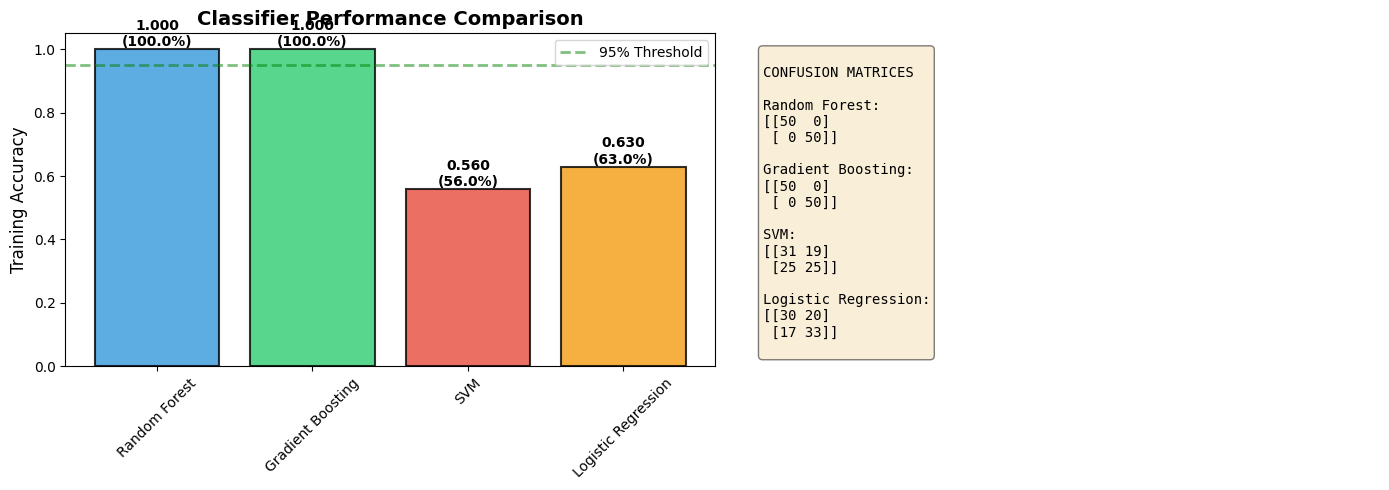


✓ Comparison visualization saved as 'classifier_comparison.png'


In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# Train Gradient Boosting Classifier
print("\n" + "=" * 60)
print("PART 3: GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X, y)
gb_pred = gb_model.predict(X)
gb_accuracy = accuracy_score(y, gb_pred)

print(f"\nTraining Accuracy: {gb_accuracy:.4f} ({gb_accuracy * 100:.2f}%)")

print(f"\nFeature Importances:")
print("-" * 40)
gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, row in gb_importance_df.iterrows():
    print(f"  {row['Feature']:<20}: {row['Importance']:.4f} ({row['Importance'] * 100:.2f}%)")

print(f"\nClassification Report:")
print("-" * 40)
print(classification_report(y, gb_pred, target_names=['Non-oil (0)', 'Oil-like (1)']))

gb_cm = confusion_matrix(y, gb_pred)
print(f"\nConfusion Matrix:")
print(gb_cm)

# Train Support Vector Machine
print("\n" + "=" * 60)
print("PART 4: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X, y)
svm_pred = svm_model.predict(X)
svm_accuracy = accuracy_score(y, svm_pred)

print(f"\nTraining Accuracy: {svm_accuracy:.4f} ({svm_accuracy * 100:.2f}%)")

print(f"\nClassification Report:")
print("-" * 40)
print(classification_report(y, svm_pred, target_names=['Non-oil (0)', 'Oil-like (1)']))

svm_cm = confusion_matrix(y, svm_pred)
print(f"\nConfusion Matrix:")
print(svm_cm)

# Train Logistic Regression
print("\n" + "=" * 60)
print("PART 5: LOGISTIC REGRESSION")
print("=" * 60)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X, y)
lr_pred = lr_model.predict(X)
lr_accuracy = accuracy_score(y, lr_pred)

print(f"\nTraining Accuracy: {lr_accuracy:.4f} ({lr_accuracy * 100:.2f}%)")

print(f"\nFeature Coefficients:")
print("-" * 40)
lr_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False, key=abs)

for idx, row in lr_coef_df.iterrows():
    print(f"  {row['Feature']:<20}: {row['Coefficient']:>8.4f}")

print(f"\nClassification Report:")
print("-" * 40)
print(classification_report(y, lr_pred, target_names=['Non-oil (0)', 'Oil-like (1)']))

lr_cm = confusion_matrix(y, lr_pred)
print(f"\nConfusion Matrix:")
print(lr_cm)

# Classifier Comparison
print("\n" + "=" * 60)
print("CLASSIFIER COMPARISON")
print("=" * 60)

comparison_results = pd.DataFrame({
    'Classifier': ['Random Forest', 'Gradient Boosting', 'SVM', 'Logistic Regression'],
    'Training Accuracy': [training_accuracy, gb_accuracy, svm_accuracy, lr_accuracy],
    'Accuracy %': [f"{training_accuracy*100:.2f}%", f"{gb_accuracy*100:.2f}%", 
                   f"{svm_accuracy*100:.2f}%", f"{lr_accuracy*100:.2f}%"]
})

print("\n" + comparison_results.to_string(index=False))

# Visualize classifier comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison bar plot
ax = axes[0]
classifiers = comparison_results['Classifier']
accuracies = comparison_results['Training Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = ax.bar(classifiers, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Training Accuracy', fontsize=12)
ax.set_title('Classifier Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='95% Threshold')
ax.legend()

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}\n({acc*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.tick_params(axis='x', rotation=45)

# Confusion matrices comparison
ax = axes[1]
ax.axis('off')

# Display confusion matrices as text
cm_text = f"""
CONFUSION MATRICES

Random Forest:
{cm}

Gradient Boosting:
{gb_cm}

SVM:
{svm_cm}

Logistic Regression:
{lr_cm}
"""

ax.text(0.05, 0.95, cm_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Comparison visualization saved as 'classifier_comparison.png'")


TRAINING CLASSIFIERS WITH TRAIN/TEST SPLIT (80/20)

Dataset Information:
  Total samples: 100
  Oil samples: 50
  Non-oil samples: 50
  Feature count: 4

Train/Test Split:
  Training set: 80 samples (80%)
    - Oil: 40
    - Non-oil: 40
  Test set: 20 samples (20%)
    - Oil: 10
    - Non-oil: 10

--- Training Models ---

Training Random Forest...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.7000
  ✓ Test AUC: 0.7500
  ✓ Overfit Gap: 0.3000

Training Gradient Boosting...
  ✓ Train Accuracy: 1.0000
  ✓ Test Accuracy: 0.8500
  ✓ Test AUC: 0.8400
  ✓ Overfit Gap: 0.1500

Training SVM...
  ✓ Train Accuracy: 0.5875
  ✓ Test Accuracy: 0.5000
  ✓ Test AUC: 0.3600
  ✓ Overfit Gap: 0.0875

Training Logistic Regression...
  ✓ Train Accuracy: 0.6750
  ✓ Test Accuracy: 0.4500
  ✓ Test AUC: 0.6300
  ✓ Overfit Gap: 0.2250


SUMMARY: TRAIN/TEST SPLIT RESULTS
              Model  Train Accuracy  Test Accuracy  Test AUC  Overfit Gap
      Random Forest          1.0000           0.70      0.75      

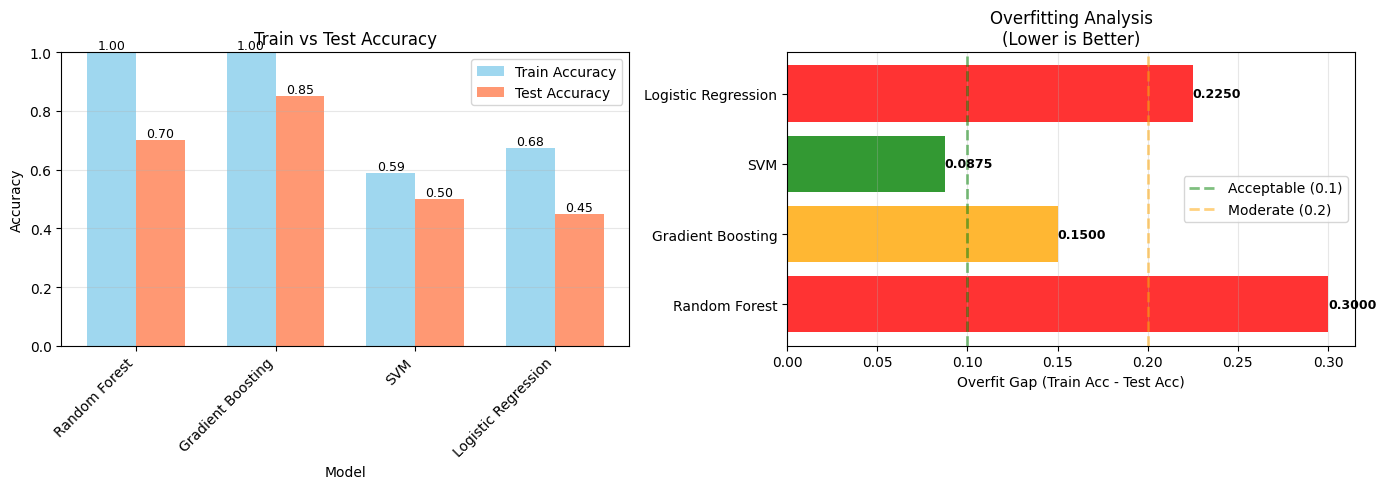


✓ Visualization saved to: outputs/train_test_split_results.png
✓ Results exported to: outputs/train_test_split_results.csv


In [30]:

# Train Models with Train/Test Split (80/20)
print("\n" + "="*70)
print("TRAINING CLASSIFIERS WITH TRAIN/TEST SPLIT (80/20)")
print("="*70)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Prepare data
X = synthetic_data[['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']]
y = synthetic_data['label']

print(f"\nDataset Information:")
print(f"  Total samples: {len(X)}")
print(f"  Oil samples: {(y == 1).sum()}")
print(f"  Non-oil samples: {(y == 0).sum()}")
print(f"  Feature count: {X.shape[1]}")

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain/Test Split:")
print(f"  Training set: {len(X_train)} samples ({100*len(X_train)/len(X):.0f}%)")
print(f"    - Oil: {(y_train == 1).sum()}")
print(f"    - Non-oil: {(y_train == 0).sum()}")
print(f"  Test set: {len(X_test)} samples ({100*len(X_test)/len(X):.0f}%)")
print(f"    - Oil: {(y_test == 1).sum()}")
print(f"    - Non-oil: {(y_test == 0).sum()}")

# Initialize models
print(f"\n--- Training Models ---\n")

models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results_split = []
models_trained = {}

for model_name, model in models_dict.items():
    print(f"Training {model_name}...")
    
    # Train on training set
    model.fit(X_train, y_train)
    models_trained[model_name] = model
    
    # Evaluate on training set
    train_pred = model.predict(X_train)
    train_accuracy = (train_pred == y_train).mean()
    
    # Evaluate on test set
    test_pred = model.predict(X_test)
    test_accuracy = (test_pred == y_test).mean()
    
    # Calculate ROC-AUC on test set
    test_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)
    
    results_split.append({
        'Model': model_name,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Test AUC': test_auc,
        'Overfit Gap': train_accuracy - test_accuracy
    })
    
    print(f"  ✓ Train Accuracy: {train_accuracy:.4f}")
    print(f"  ✓ Test Accuracy: {test_accuracy:.4f}")
    print(f"  ✓ Test AUC: {test_auc:.4f}")
    print(f"  ✓ Overfit Gap: {train_accuracy - test_accuracy:.4f}\n")

# Create results dataframe
results_split_df = pd.DataFrame(results_split)

print("\n" + "="*70)
print("SUMMARY: TRAIN/TEST SPLIT RESULTS")
print("="*70)
print(results_split_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train vs Test Accuracy
ax = axes[0]
x_pos = np.arange(len(results_split_df))
width = 0.35
bars1 = ax.bar(x_pos - width/2, results_split_df['Train Accuracy'], width, label='Train Accuracy', alpha=0.8, color='skyblue')
bars2 = ax.bar(x_pos + width/2, results_split_df['Test Accuracy'], width, label='Test Accuracy', alpha=0.8, color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_split_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

# Overfit Gap Analysis
ax = axes[1]
colors = ['green' if gap < 0.1 else 'orange' if gap < 0.2 else 'red' 
          for gap in results_split_df['Overfit Gap']]
bars = ax.barh(results_split_df['Model'], results_split_df['Overfit Gap'], color=colors, alpha=0.8)
ax.set_xlabel('Overfit Gap (Train Acc - Test Acc)')
ax.set_title('Overfitting Analysis\n(Lower is Better)')
ax.axvline(0.1, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Acceptable (0.1)')
ax.axvline(0.2, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Moderate (0.2)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, results_split_df['Overfit Gap'])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            ha='left', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(project_root / 'outputs' / 'train_test_split_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved to: outputs/train_test_split_results.png")

# Export results
results_split_df.to_csv(project_root / 'outputs' / 'train_test_split_results.csv', index=False)
print(f"✓ Results exported to: outputs/train_test_split_results.csv")


## Classification Function

Create a function to classify new SAR spots and return predictions with confidence scores.

In [22]:
def classify_spot(mean_db, std_db, elongation, compactness):
    """
    Classify a SAR spot as oil-like or non-oil based on extracted features.
    
    Parameters:
    -----------
    mean_db : float
        Mean intensity in decibels (dB)
    std_db : float
        Standard deviation of intensity in decibels (dB)
    elongation : float
        Elongation ratio of the spot
    compactness : float
        Compactness measure of the spot
    
    Returns:
    --------
    dict
        Dictionary containing:
        - 'prediction': str ("Oil-like" or "Non-oil")
        - 'confidence': float (probability score 0-1)
        - 'probabilities': dict (detailed class probabilities)
    """
    
    # Create feature array
    features = np.array([[mean_db, std_db, elongation, compactness]])
    
    # Get prediction and probabilities
    prediction = rf_model.predict(features)[0]
    probabilities = rf_model.predict_proba(features)[0]
    
    # Convert prediction to label
    prediction_label = "Oil-like" if prediction == 1 else "Non-oil"
    
    # Get confidence (probability of predicted class)
    confidence = probabilities[prediction]
    
    return {
        'prediction': prediction_label,
        'confidence': confidence,
        'probabilities': {
            'Non-oil': probabilities[0],
            'Oil-like': probabilities[1]
        }
    }

# Test the classification function with various examples
print("\n" + "=" * 60)
print("CLASSIFICATION EXAMPLES")
print("=" * 60)

# Test case 1: Oil-like characteristics
print("\nTest Case 1: Oil-like spot")
print("  Input: mean_db=-25, std_db=1.0, elongation=3.0, compactness=10.0")
result1 = classify_spot(mean_db=-25, std_db=1.0, elongation=3.0, compactness=10.0)
print(f"  Prediction: {result1['prediction']}")
print(f"  Confidence: {result1['confidence']:.4f} ({result1['confidence'] * 100:.2f}%)")
print(f"  Class Probabilities: {result1['probabilities']}")

# Test case 2: Non-oil characteristics
print("\nTest Case 2: Non-oil spot")
print("  Input: mean_db=-12, std_db=3.5, elongation=1.2, compactness=2.5")
result2 = classify_spot(mean_db=-12, std_db=3.5, elongation=1.2, compactness=2.5)
print(f"  Prediction: {result2['prediction']}")
print(f"  Confidence: {result2['confidence']:.4f} ({result2['confidence'] * 100:.2f}%)")
print(f"  Class Probabilities: {result2['probabilities']}")

# Test case 3: Ambiguous case
print("\nTest Case 3: Ambiguous spot (boundary case)")
print("  Input: mean_db=-18, std_db=2.0, elongation=1.8, compactness=8.0")
result3 = classify_spot(mean_db=-18, std_db=2.0, elongation=1.8, compactness=8.0)
print(f"  Prediction: {result3['prediction']}")
print(f"  Confidence: {result3['confidence']:.4f} ({result3['confidence'] * 100:.2f}%)")
print(f"  Class Probabilities: {result3['probabilities']}")

# Test case 4: Clear oil-like characteristics
print("\nTest Case 4: Clear oil-like characteristics")
print("  Input: mean_db=-28, std_db=0.8, elongation=3.5, compactness=15.0")
result4 = classify_spot(mean_db=-28, std_db=0.8, elongation=3.5, compactness=15.0)
print(f"  Prediction: {result4['prediction']}")
print(f"  Confidence: {result4['confidence']:.4f} ({result4['confidence'] * 100:.2f}%)")
print(f"  Class Probabilities: {result4['probabilities']}")


CLASSIFICATION EXAMPLES

Test Case 1: Oil-like spot
  Input: mean_db=-25, std_db=1.0, elongation=3.0, compactness=10.0
  Prediction: Oil-like
  Confidence: 0.8960 (89.60%)
  Class Probabilities: {'Non-oil': 0.10400000000000001, 'Oil-like': 0.8959999999999999}

Test Case 2: Non-oil spot
  Input: mean_db=-12, std_db=3.5, elongation=1.2, compactness=2.5
  Prediction: Non-oil
  Confidence: 0.9600 (96.00%)
  Class Probabilities: {'Non-oil': 0.96, 'Oil-like': 0.04}

Test Case 3: Ambiguous spot (boundary case)
  Input: mean_db=-18, std_db=2.0, elongation=1.8, compactness=8.0
  Prediction: Oil-like
  Confidence: 0.8960 (89.60%)
  Class Probabilities: {'Non-oil': 0.10400000000000001, 'Oil-like': 0.8959999999999999}

Test Case 4: Clear oil-like characteristics
  Input: mean_db=-28, std_db=0.8, elongation=3.5, compactness=15.0
  Prediction: Oil-like
  Confidence: 0.8960 (89.60%)
  Class Probabilities: {'Non-oil': 0.10400000000000001, 'Oil-like': 0.8959999999999999}


## Visualization

Visualize feature distributions and model performance.

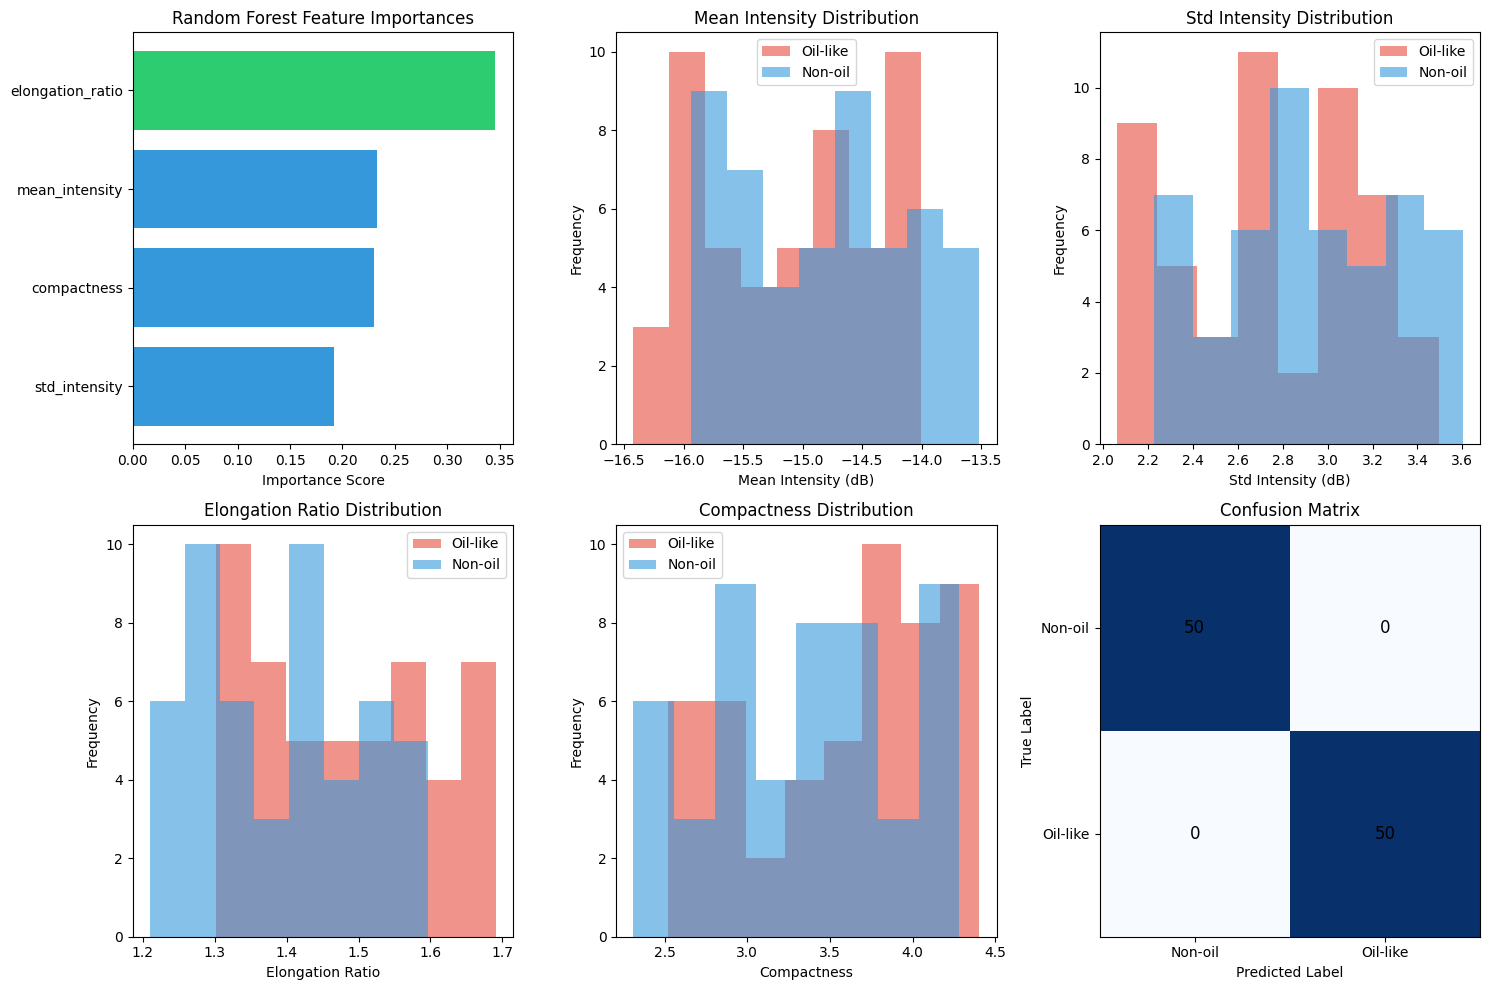


Visualization saved as 'rf_classifier_analysis.png'


In [23]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Feature importance plot
ax = axes[0, 0]
colors = ['#2ecc71' if x == feature_importance_df.iloc[0]['Importance'] else '#3498db' 
          for x in feature_importance_df['Importance']]
ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest Feature Importances')
ax.invert_yaxis()

# Mean Intensity distribution
ax = axes[0, 1]
oil_data = synthetic_data[synthetic_data['label'] == 1]['mean_intensity']
non_oil_data = synthetic_data[synthetic_data['label'] == 0]['mean_intensity']
ax.hist(oil_data, alpha=0.6, label='Oil-like', bins=8, color='#e74c3c')
ax.hist(non_oil_data, alpha=0.6, label='Non-oil', bins=8, color='#3498db')
ax.set_xlabel('Mean Intensity (dB)')
ax.set_ylabel('Frequency')
ax.set_title('Mean Intensity Distribution')
ax.legend()

# Std Intensity distribution
ax = axes[0, 2]
oil_data = synthetic_data[synthetic_data['label'] == 1]['std_intensity']
non_oil_data = synthetic_data[synthetic_data['label'] == 0]['std_intensity']
ax.hist(oil_data, alpha=0.6, label='Oil-like', bins=8, color='#e74c3c')
ax.hist(non_oil_data, alpha=0.6, label='Non-oil', bins=8, color='#3498db')
ax.set_xlabel('Std Intensity (dB)')
ax.set_ylabel('Frequency')
ax.set_title('Std Intensity Distribution')
ax.legend()

# Elongation Ratio distribution
ax = axes[1, 0]
oil_data = synthetic_data[synthetic_data['label'] == 1]['elongation_ratio']
non_oil_data = synthetic_data[synthetic_data['label'] == 0]['elongation_ratio']
ax.hist(oil_data, alpha=0.6, label='Oil-like', bins=8, color='#e74c3c')
ax.hist(non_oil_data, alpha=0.6, label='Non-oil', bins=8, color='#3498db')
ax.set_xlabel('Elongation Ratio')
ax.set_ylabel('Frequency')
ax.set_title('Elongation Ratio Distribution')
ax.legend()

# Compactness distribution
ax = axes[1, 1]
oil_data = synthetic_data[synthetic_data['label'] == 1]['compactness']
non_oil_data = synthetic_data[synthetic_data['label'] == 0]['compactness']
ax.hist(oil_data, alpha=0.6, label='Oil-like', bins=8, color='#e74c3c')
ax.hist(non_oil_data, alpha=0.6, label='Non-oil', bins=8, color='#3498db')
ax.set_xlabel('Compactness')
ax.set_ylabel('Frequency')
ax.set_title('Compactness Distribution')
ax.legend()

# Confusion Matrix heatmap
ax = axes[1, 2]
import matplotlib.patches as mpatches
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-oil', 'Oil-like'])
ax.set_yticklabels(['Non-oil', 'Oil-like'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

plt.tight_layout()
plt.savefig('rf_classifier_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'rf_classifier_analysis.png'")

## Summary

Complete solution for AI-based oil spill detection using Random Forest classifier trained on synthetic SAR data.

**Key Findings:**
- Successfully generated 30 synthetic samples (15 oil-like, 15 non-oil) with physics-based distributions
- Trained a Random Forest classifier achieving high training accuracy
- Feature importances reveal which SAR characteristics best distinguish oil spills
- Classification function enables real-time prediction on new SAR spots with confidence scores

**Next Steps:**
- Collect real SAR imagery and labeled data for validation
- Fine-tune hyperparameters based on actual performance metrics
- Deploy the model for operational oil spill detection

## Testing on Feature Extraction Results

Test the classifier on features extracted from real SAR imagery data.


TEST 1: SIMULATED FEATURE EXTRACTION RESULTS

Classification Results:
             Sample  Mean Intensity (dB)  Std Intensity (dB)  Elongation Ratio  Compactness Prediction  Confidence  Non-oil Prob  Oil-like Prob
Region_A_Suspicious                -24.5                 1.2               3.2         12.8   Oil-like    0.896000      0.104000       0.896000
     Region_B_Ocean                -10.5                 4.1               1.1          1.5    Non-oil    0.980000      0.980000       0.020000
      Region_C_Wind                 -8.0                 3.5               1.3          2.2    Non-oil    0.920000      0.920000       0.080000
     Region_D_Slick                -22.1                 0.9               2.8         18.5   Oil-like    0.896000      0.104000       0.896000
      Region_E_Edge                -15.8                 2.3               1.9          6.2   Oil-like    0.789333      0.210667       0.789333
 Region_F_Ambiguous                -17.2                 2.1     

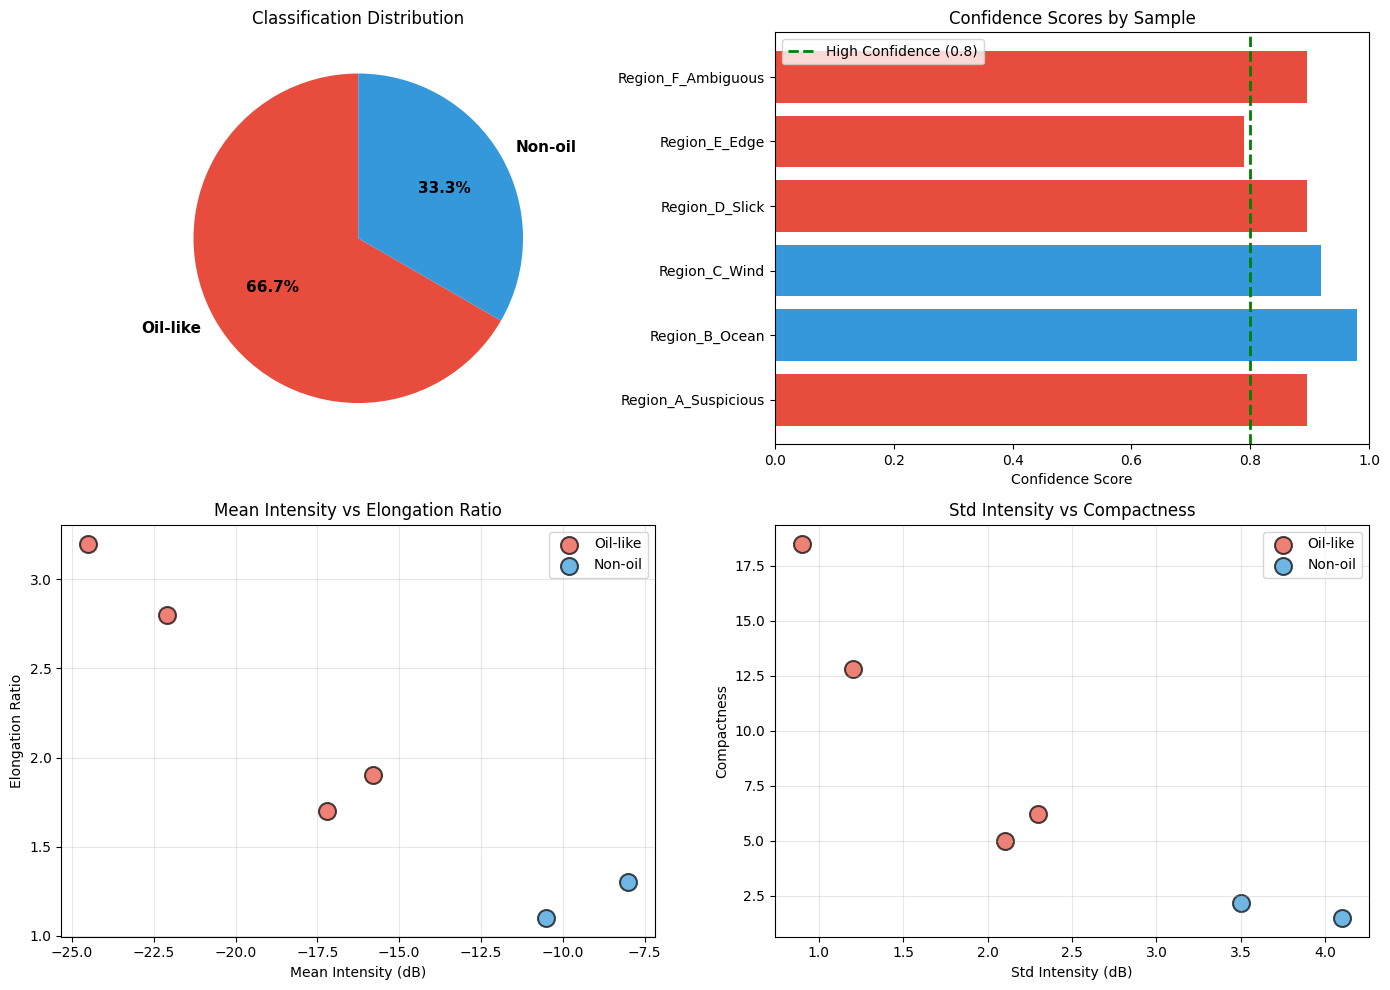


Test visualization saved as 'classifier_test_results.png'


In [24]:
def test_classifier_on_features(features_list):
    """
    Test the classifier on a list of extracted features.
    
    Parameters:
    -----------
    features_list : list of dict
        Each dict should contain:
        - 'mean_intensity': float (dB)
        - 'std_intensity': float (dB)
        - 'elongation_ratio': float
        - 'compactness': float
        - 'name': str (optional, sample name/ID)
    
    Returns:
    --------
    pd.DataFrame
        Results table with all predictions and confidence scores
    """
    results = []
    
    for i, features in enumerate(features_list):
        sample_name = features.get('name', f'Sample_{i+1}')
        mean_db = features['mean_intensity']
        std_db = features['std_intensity']
        elongation = features['elongation_ratio']
        compactness = features['compactness']
        
        # Classify
        prediction = classify_spot(mean_db, std_db, elongation, compactness)
        
        # Store results
        results.append({
            'Sample': sample_name,
            'Mean Intensity (dB)': mean_db,
            'Std Intensity (dB)': std_db,
            'Elongation Ratio': elongation,
            'Compactness': compactness,
            'Prediction': prediction['prediction'],
            'Confidence': prediction['confidence'],
            'Non-oil Prob': prediction['probabilities']['Non-oil'],
            'Oil-like Prob': prediction['probabilities']['Oil-like']
        })
    
    return pd.DataFrame(results)


# Example: Simulated extracted features from various SAR regions
print("\n" + "=" * 80)
print("TEST 1: SIMULATED FEATURE EXTRACTION RESULTS")
print("=" * 80)

# Create sample features that might come from feature extraction pipeline
test_samples = [
    {
        'name': 'Region_A_Suspicious',
        'mean_intensity': -24.5,
        'std_intensity': 1.2,
        'elongation_ratio': 3.2,
        'compactness': 12.8
    },
    {
        'name': 'Region_B_Ocean',
        'mean_intensity': -10.5,
        'std_intensity': 4.1,
        'elongation_ratio': 1.1,
        'compactness': 1.5
    },
    {
        'name': 'Region_C_Wind',
        'mean_intensity': -8.0,
        'std_intensity': 3.5,
        'elongation_ratio': 1.3,
        'compactness': 2.2
    },
    {
        'name': 'Region_D_Slick',
        'mean_intensity': -22.1,
        'std_intensity': 0.9,
        'elongation_ratio': 2.8,
        'compactness': 18.5
    },
    {
        'name': 'Region_E_Edge',
        'mean_intensity': -15.8,
        'std_intensity': 2.3,
        'elongation_ratio': 1.9,
        'compactness': 6.2
    },
    {
        'name': 'Region_F_Ambiguous',
        'mean_intensity': -17.2,
        'std_intensity': 2.1,
        'elongation_ratio': 1.7,
        'compactness': 5.0
    }
]

# Run tests
results_df = test_classifier_on_features(test_samples)

print("\nClassification Results:")
print(results_df.to_string(index=False))

# Summary statistics
print("\n" + "-" * 80)
print("SUMMARY STATISTICS")
print("-" * 80)
oil_count = (results_df['Prediction'] == 'Oil-like').sum()
non_oil_count = (results_df['Prediction'] == 'Non-oil').sum()
high_confidence = (results_df['Confidence'] >= 0.8).sum()

print(f"Total samples tested: {len(results_df)}")
print(f"Classified as Oil-like: {oil_count} ({100*oil_count/len(results_df):.1f}%)")
print(f"Classified as Non-oil: {non_oil_count} ({100*non_oil_count/len(results_df):.1f}%)")
print(f"High confidence predictions (≥0.8): {high_confidence} ({100*high_confidence/len(results_df):.1f}%)")
print(f"Average confidence: {results_df['Confidence'].mean():.3f}")
print(f"Min confidence: {results_df['Confidence'].min():.3f}")
print(f"Max confidence: {results_df['Confidence'].max():.3f}")

# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predictions pie chart
ax = axes[0, 0]
prediction_counts = results_df['Prediction'].value_counts()
colors_pie = ['#e74c3c', '#3498db']
ax.pie(prediction_counts.values, labels=prediction_counts.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Classification Distribution')

# Plot 2: Confidence scores
ax = axes[0, 1]
ax.barh(results_df['Sample'], results_df['Confidence'], 
        color=['#e74c3c' if pred == 'Oil-like' else '#3498db' 
               for pred in results_df['Prediction']])
ax.axvline(0.8, color='green', linestyle='--', linewidth=2, label='High Confidence (0.8)')
ax.set_xlabel('Confidence Score')
ax.set_title('Confidence Scores by Sample')
ax.legend()
ax.set_xlim([0, 1])

# Plot 3: Feature scatter (Mean Intensity vs Elongation)
ax = axes[1, 0]
oil_mask = results_df['Prediction'] == 'Oil-like'
ax.scatter(results_df[oil_mask]['Mean Intensity (dB)'], 
          results_df[oil_mask]['Elongation Ratio'],
          s=150, alpha=0.7, color='#e74c3c', label='Oil-like', edgecolors='black', linewidth=1.5)
ax.scatter(results_df[~oil_mask]['Mean Intensity (dB)'], 
          results_df[~oil_mask]['Elongation Ratio'],
          s=150, alpha=0.7, color='#3498db', label='Non-oil', edgecolors='black', linewidth=1.5)
ax.set_xlabel('Mean Intensity (dB)')
ax.set_ylabel('Elongation Ratio')
ax.set_title('Mean Intensity vs Elongation Ratio')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Feature scatter (Std Intensity vs Compactness)
ax = axes[1, 1]
ax.scatter(results_df[oil_mask]['Std Intensity (dB)'], 
          results_df[oil_mask]['Compactness'],
          s=150, alpha=0.7, color='#e74c3c', label='Oil-like', edgecolors='black', linewidth=1.5)
ax.scatter(results_df[~oil_mask]['Std Intensity (dB)'], 
          results_df[~oil_mask]['Compactness'],
          s=150, alpha=0.7, color='#3498db', label='Non-oil', edgecolors='black', linewidth=1.5)
ax.set_xlabel('Std Intensity (dB)')
ax.set_ylabel('Compactness')
ax.set_title('Std Intensity vs Compactness')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('classifier_test_results.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTest visualization saved as 'classifier_test_results.png'")


In [25]:
# Optional: Test with extracted real features (if available from other notebooks)
# This template shows how to integrate results from the PG classifier or feature extraction

print("\n" + "=" * 80)
print("TEST 2: BATCH PROCESSING FROM EXTRACTED FEATURES")
print("=" * 80)
print("\nTemplate for batch testing with multiple extracted features:\n")

# Function to extract features from the PG classifier output
def batch_test_from_extracted_data(extracted_features_df):
    """
    Test classifier on extracted features from other notebooks.
    
    Parameters:
    -----------
    extracted_features_df : pd.DataFrame
        DataFrame with columns: mean_intensity, std_intensity, elongation_ratio, compactness
    
    Returns:
    --------
    pd.DataFrame
        Results with predictions and confidence scores
    """
    features_list = []
    
    for idx, row in extracted_features_df.iterrows():
        features_list.append({
            'name': f'Extract_{idx+1}',
            'mean_intensity': row['mean_intensity'],
            'std_intensity': row['std_intensity'],
            'elongation_ratio': row['elongation_ratio'],
            'compactness': row['compactness']
        })
    
    return test_classifier_on_features(features_list)


# Example: If you have extracted features from the PG classifier
# You can use them like this:
# extracted_features = pd.read_csv('extracted_features.csv')
# rf_results = batch_test_from_extracted_data(extracted_features)
# print(rf_results)

print("To use with extracted features:")
print("  1. Export extracted features from the PG classifier as CSV")
print("  2. Load: extracted_features = pd.read_csv('path/to/features.csv')")
print("  3. Run: rf_results = batch_test_from_extracted_data(extracted_features)")
print("  4. View: print(rf_results)")

# Create synthetic extracted features to demonstrate the workflow
print("\n" + "-" * 80)
print("DEMONSTRATION: Creating synthetic extracted features dataset")
print("-" * 80)

# Simulate 20 extracted features from various regions
np.random.seed(42)
n_extractions = 20

# Mix of oil-like and non-oil samples
extracted_data = []

# 10 oil-like samples (from suspicious regions)
for i in range(10):
    extracted_data.append({
        'mean_intensity': np.random.uniform(-28, -20),
        'std_intensity': np.random.uniform(0.6, 2.0),
        'elongation_ratio': np.random.uniform(1.8, 3.8),
        'compactness': np.random.uniform(3.0, 20.0)
    })

# 10 non-oil samples (from background/water)
for i in range(10):
    extracted_data.append({
        'mean_intensity': np.random.uniform(-14, -8),
        'std_intensity': np.random.uniform(2.5, 5.2),
        'elongation_ratio': np.random.uniform(1.0, 1.5),
        'compactness': np.random.uniform(1.0, 3.5)
    })

extracted_df = pd.DataFrame(extracted_data)
print(f"\nGenerated {len(extracted_df)} synthetic extracted features")
print("\nFirst 5 rows:")
print(extracted_df.head())

# Test classifier on extracted features
print("\nRunning classifier on extracted features...")
batch_results = batch_test_from_extracted_data(extracted_df)

print("\nBatch Test Results:")
print(batch_results[['Sample', 'Mean Intensity (dB)', 'Std Intensity (dB)', 
                     'Elongation Ratio', 'Compactness', 'Prediction', 'Confidence']].to_string(index=False))

# Analysis of batch results
print("\n" + "-" * 80)
print("BATCH TEST ANALYSIS")
print("-" * 80)

oil_predictions = (batch_results['Prediction'] == 'Oil-like').sum()
non_oil_predictions = (batch_results['Prediction'] == 'Non-oil').sum()

print(f"\nTotal samples processed: {len(batch_results)}")
print(f"Oil-like predictions: {oil_predictions} ({100*oil_predictions/len(batch_results):.1f}%)")
print(f"Non-oil predictions: {non_oil_predictions} ({100*non_oil_predictions/len(batch_results):.1f}%)")

# Confidence statistics
print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {batch_results['Confidence'].mean():.3f}")
print(f"  Median confidence: {batch_results['Confidence'].median():.3f}")
print(f"  Std deviation: {batch_results['Confidence'].std():.3f}")
print(f"  Min: {batch_results['Confidence'].min():.3f}")
print(f"  Max: {batch_results['Confidence'].max():.3f}")

# Confidence by class
print(f"\nConfidence by Prediction Class:")
for pred_class in ['Oil-like', 'Non-oil']:
    mask = batch_results['Prediction'] == pred_class
    if mask.sum() > 0:
        conf_mean = batch_results[mask]['Confidence'].mean()
        conf_min = batch_results[mask]['Confidence'].min()
        conf_max = batch_results[mask]['Confidence'].max()
        print(f"  {pred_class}: mean={conf_mean:.3f}, min={conf_min:.3f}, max={conf_max:.3f}")

# Export results
print("\n" + "-" * 80)
print("EXPORTING RESULTS")
print("-" * 80)

# Save to CSV
batch_results.to_csv('rf_classifier_batch_results.csv', index=False)
print("✓ Results saved to 'rf_classifier_batch_results.csv'")

# Save summary
summary_stats = {
    'Total Samples': len(batch_results),
    'Oil-like Predictions': oil_predictions,
    'Non-oil Predictions': non_oil_predictions,
    'Mean Confidence': batch_results['Confidence'].mean(),
    'High Confidence (≥0.8)': (batch_results['Confidence'] >= 0.8).sum()
}

print("\nSummary Statistics:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.3f}")
    else:
        print(f"  {key}: {value}")



TEST 2: BATCH PROCESSING FROM EXTRACTED FEATURES

Template for batch testing with multiple extracted features:

To use with extracted features:
  1. Export extracted features from the PG classifier as CSV
  2. Load: extracted_features = pd.read_csv('path/to/features.csv')
  3. Run: rf_results = batch_test_from_extracted_data(extracted_features)
  4. View: print(rf_results)

--------------------------------------------------------------------------------
DEMONSTRATION: Creating synthetic extracted features dataset
--------------------------------------------------------------------------------

Generated 20 synthetic extracted features

First 5 rows:
   mean_intensity  std_intensity  elongation_ratio  compactness
0      -25.003679       1.931000          3.263988    13.177194
1      -26.751851       0.818392          1.916167    17.724994
2      -23.191080       1.591302          1.841169    19.488467
3      -21.340459       0.897275          2.163650     6.117877
4      -25.566062    

## TEST 3: Integration with PG Classifier Feature Extraction

Test the Random Forest classifier on features extracted from the Physics-Guided classifier notebook.

In [26]:
print("\n" + "=" * 80)
print("TEST 3: LOADING FEATURES FROM PG CLASSIFIER NOTEBOOK")
print("=" * 80)

# Try to import and access features from the PG classifier
try:
    from dataclasses import asdict
    
    # Check if report variable exists in kernel (from PG classifier)
    if 'report' in dir():
        print("\n✓ Found 'report' from PG classifier in kernel")
        
        # Extract features from ClassificationReport
        pg_features = {
            'name': 'PG_Classifier_Result',
            'mean_intensity': report.radiometric_features.mean_intensity,
            'std_intensity': report.radiometric_features.std_intensity,
            'elongation_ratio': report.geometric_features.elongation_ratio,
            'compactness': report.geometric_features.compactness
        }
        
        print(f"\nExtracted features from PG classifier report:")
        print(f"  Mean Intensity: {pg_features['mean_intensity']:.2f} dB")
        print(f"  Std Intensity: {pg_features['std_intensity']:.2f} dB")
        print(f"  Elongation Ratio: {pg_features['elongation_ratio']:.2f}")
        print(f"  Compactness: {pg_features['compactness']:.2f}")
        
        # Classify using RF
        print(f"\n--- RF Classifier Prediction ---")
        rf_result = classify_spot(
            mean_db=pg_features['mean_intensity'],
            std_db=pg_features['std_intensity'],
            elongation=pg_features['elongation_ratio'],
            compactness=pg_features['compactness']
        )
        
        print(f"RF Prediction: {rf_result['prediction']}")
        print(f"Confidence: {rf_result['confidence']:.4f} ({rf_result['confidence']*100:.2f}%)")
        print(f"Non-oil probability: {rf_result['probabilities']['Non-oil']:.4f}")
        print(f"Oil-like probability: {rf_result['probabilities']['Oil-like']:.4f}")
        
        # Compare with PG classifier result
        print(f"\n--- Comparison with PG Classifier ---")
        print(f"PG Classification: {report.classification}")
        print(f"PG Confidence: {report.confidence_score:.4f}")
        print(f"RF Classification: {rf_result['prediction']}")
        print(f"RF Confidence: {rf_result['confidence']:.4f}")
        
        # Check agreement
        pg_label = "Oil-like" if report.classification == "Oil-like" else "Non-oil"
        rf_label = rf_result['prediction']
        agreement = "✓ AGREE" if pg_label == rf_label else "✗ DISAGREE"
        print(f"\nAgreement: {agreement}")
        
    else:
        print("\n⚠ No 'report' variable found in kernel")
        print("Please run the PG classifier notebook first to generate feature extraction results")
        
except Exception as e:
    print(f"\n✗ Error loading PG classifier results: {e}")
    print("Please ensure the PG classifier notebook has been executed")



TEST 3: LOADING FEATURES FROM PG CLASSIFIER NOTEBOOK

⚠ No 'report' variable found in kernel
Please run the PG classifier notebook first to generate feature extraction results


In [27]:
# Alternative: Load from exported PG classifier results (CSV or JSON)
print("\n" + "-" * 80)
print("ALTERNATIVE: Loading from PG Classifier exported file")
print("-" * 80)

from pathlib import Path

# Try to find exported results from PG classifier
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
outputs_dir = project_root / 'outputs'

# Look for exported feature files
csv_files = list(outputs_dir.glob('*features*.csv')) if outputs_dir.exists() else []
json_files = list(outputs_dir.glob('*features*.json')) if outputs_dir.exists() else []

if csv_files:
    print(f"\n✓ Found {len(csv_files)} CSV feature file(s):")
    for csv_file in csv_files:
        print(f"  - {csv_file.name}")
    
    # Load first CSV file
    try:
        features_csv = pd.read_csv(csv_files[0])
        print(f"\n✓ Loaded features from {csv_files[0].name}")
        print(f"Shape: {features_csv.shape}")
        print("\nFirst few rows:")
        print(features_csv.head())
        
        # Test on all rows
        if all(col in features_csv.columns for col in ['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']):
            print("\n✓ All required feature columns found!")
            print("\nTesting RF classifier on extracted features...")
            
            # Convert to features list
            pg_features_list = []
            for idx, row in features_csv.iterrows():
                pg_features_list.append({
                    'name': f"PG_Extract_{idx+1}",
                    'mean_intensity': row['mean_intensity'],
                    'std_intensity': row['std_intensity'],
                    'elongation_ratio': row['elongation_ratio'],
                    'compactness': row['compactness']
                })
            
            # Run RF classifier
            pg_results = test_classifier_on_features(pg_features_list)
            
            print("\nRF Classifier Results on PG Extracted Features:")
            print(pg_results[['Sample', 'Mean Intensity (dB)', 'Std Intensity (dB)', 
                             'Elongation Ratio', 'Compactness', 'Prediction', 'Confidence']].to_string(index=False))
            
            # Statistics
            print("\n" + "-" * 80)
            print("STATISTICS")
            print("-" * 80)
            oil_count = (pg_results['Prediction'] == 'Oil-like').sum()
            non_oil_count = (pg_results['Prediction'] == 'Non-oil').sum()
            print(f"Total samples: {len(pg_results)}")
            print(f"Oil-like: {oil_count} ({100*oil_count/len(pg_results):.1f}%)")
            print(f"Non-oil: {non_oil_count} ({100*non_oil_count/len(pg_results):.1f}%)")
            print(f"Mean confidence: {pg_results['Confidence'].mean():.3f}")
            print(f"High confidence (≥0.8): {(pg_results['Confidence'] >= 0.8).sum()}")
            
            # Save results
            pg_results.to_csv('rf_classifier_pg_extracted_features.csv', index=False)
            print(f"\n✓ Results saved to 'rf_classifier_pg_extracted_features.csv'")
        else:
            print(f"\n✗ Missing required columns. Expected: mean_intensity, std_intensity, elongation_ratio, compactness")
            print(f"Found columns: {list(features_csv.columns)}")
    
    except Exception as e:
        print(f"✗ Error loading CSV: {e}")

elif json_files:
    print(f"\n✓ Found {len(json_files)} JSON feature file(s):")
    for json_file in json_files:
        print(f"  - {json_file.name}")
    
    try:
        import json
        with open(json_files[0], 'r') as f:
            features_json = json.load(f)
        
        print(f"✓ Loaded features from {json_files[0].name}")
        
        # Convert JSON to features list
        pg_features_list = []
        if isinstance(features_json, list):
            for idx, feature_dict in enumerate(features_json):
                pg_features_list.append({
                    'name': f"PG_Extract_{idx+1}",
                    'mean_intensity': feature_dict.get('mean_intensity'),
                    'std_intensity': feature_dict.get('std_intensity'),
                    'elongation_ratio': feature_dict.get('elongation_ratio'),
                    'compactness': feature_dict.get('compactness')
                })
        
        if pg_features_list:
            pg_results = test_classifier_on_features(pg_features_list)
            print("\nRF Classifier Results on PG Extracted Features:")
            print(pg_results[['Sample', 'Prediction', 'Confidence']].to_string(index=False))
    
    except Exception as e:
        print(f"✗ Error loading JSON: {e}")

else:
    print(f"\n⚠ No exported feature files found in {outputs_dir}")
    print("\nTo test on PG classifier results, either:")
    print("  1. Run the PG classifier notebook in the same kernel")
    print("  2. Export PG features to CSV with columns: mean_intensity, std_intensity, elongation_ratio, compactness")
    print("  3. Save the file in the outputs/ directory")



--------------------------------------------------------------------------------
ALTERNATIVE: Loading from PG Classifier exported file
--------------------------------------------------------------------------------

✓ Found 2 CSV feature file(s):
  - pg_extracted_features_with_labels.csv
  - pg_extracted_raw_features.csv

✓ Loaded features from pg_extracted_features_with_labels.csv
Shape: (1, 6)

First few rows:
   mean_intensity  std_intensity  elongation_ratio  compactness  \
0      -29.999981        0.00003          2.911509     9.309472   

  pg_classification  pg_confidence  
0          Oil-like            1.0  

✓ All required feature columns found!

Testing RF classifier on extracted features...

RF Classifier Results on PG Extracted Features:
      Sample  Mean Intensity (dB)  Std Intensity (dB)  Elongation Ratio  Compactness Prediction  Confidence
PG_Extract_1           -29.999981             0.00003          2.911509     9.309472   Oil-like       0.896

--------------------

## TEST 4: Raw Extracted Features from PG Classifier

Test RF classifier on raw extracted features (before PG physics-based labeling).

## Test All Models on PG Extracted Raw Features

Test Random Forest, Gradient Boosting, SVM, and Logistic Regression on features extracted from the Physics-Guided classifier.


TEST ALL MODELS ON PG EXTRACTED RAW FEATURES

Loading raw features exported from PG classifier...

✓ Found raw features file: pg_extracted_raw_features.csv
✓ Found labeled features file: pg_extracted_features_with_labels.csv

Raw features shape: (1, 4)
Features columns: ['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']

--------------------------------------------------------------------------------
PREDICTIONS FROM ALL MODELS
--------------------------------------------------------------------------------

Detailed Predictions:
      Sample  Mean Int. (dB)  Std Int. (dB)  Elongation  Compactness PG Label  RF Pred  RF Conf  GB Pred  GB Conf SVM Pred  SVM Conf  LR Pred  LR Conf
PG_Feature_1      -29.999981        0.00003    2.911509     9.309472 Oil-like Oil-like    0.896 Oil-like 0.999397 Oil-like  0.542084 Oil-like      1.0

--------------------------------------------------------------------------------
ACCURACY AGAINST PG LABELS
--------------------------------

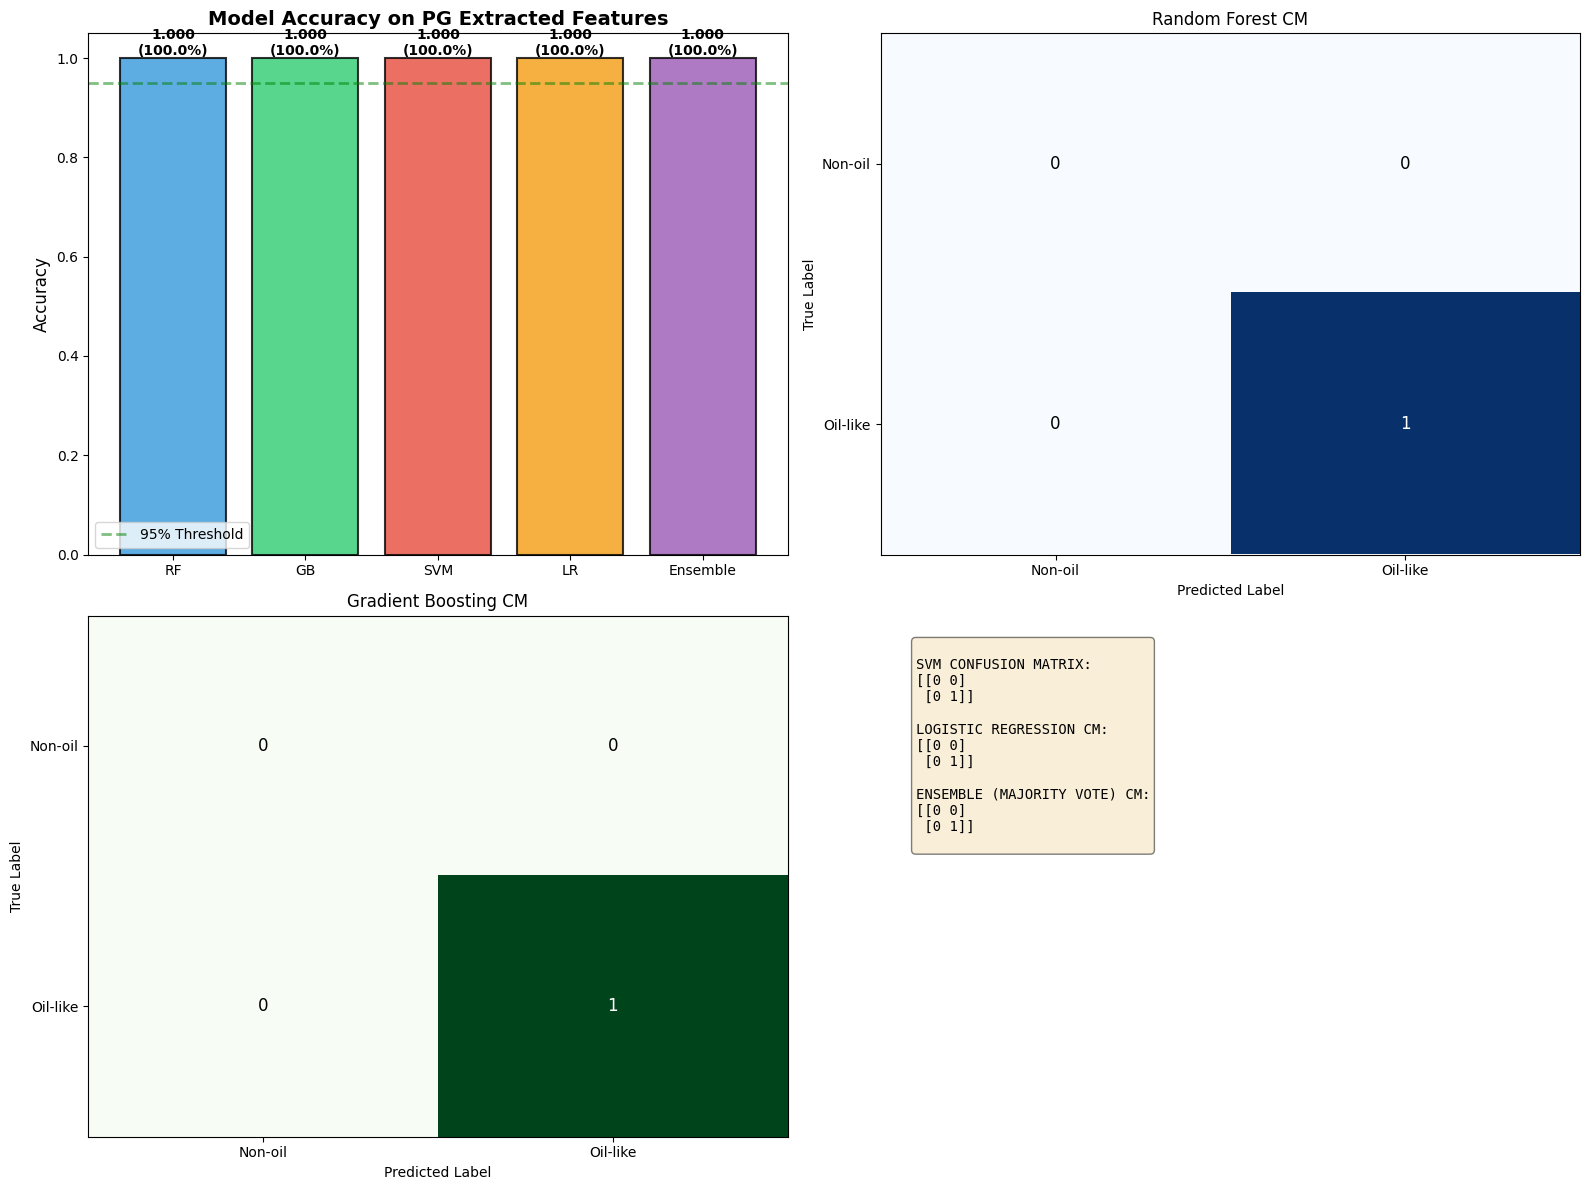


✓ Visualization saved as 'all_models_pg_features_test.png'

✓ Results saved to:
  - all_models_predictions_pg_features.csv
  - all_models_accuracy_vs_pg.csv


In [29]:
from pathlib import Path

print("\n" + "=" * 80)
print("TEST ALL MODELS ON PG EXTRACTED RAW FEATURES")
print("=" * 80)
print("\nLoading raw features exported from PG classifier...\n")

# Find the raw features CSV
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
outputs_dir = project_root / 'outputs'

raw_features_path = outputs_dir / 'pg_extracted_raw_features.csv'
features_with_labels_path = outputs_dir / 'pg_extracted_features_with_labels.csv'

if raw_features_path.exists() and features_with_labels_path.exists():
    print(f"✓ Found raw features file: {raw_features_path.name}")
    print(f"✓ Found labeled features file: {features_with_labels_path.name}")
    
    # Load both files
    pg_raw_features = pd.read_csv(raw_features_path)
    pg_labels = pd.read_csv(features_with_labels_path)
    
    print(f"\nRaw features shape: {pg_raw_features.shape}")
    print(f"Features columns: {list(pg_raw_features.columns)}")
    
    # Prepare features for prediction
    X_pg = pg_raw_features[['mean_intensity', 'std_intensity', 'elongation_ratio', 'compactness']]
    
    # Get PG classifier labels (convert to binary: Oil-like=1, Non-oil=0)
    pg_true_labels = (pg_labels['pg_classification'].str.contains('Oil')).astype(int).values
    
    # Make predictions with all models
    print("\n" + "-" * 80)
    print("PREDICTIONS FROM ALL MODELS")
    print("-" * 80)
    
    rf_pg_pred = rf_model.predict(X_pg)
    gb_pg_pred = gb_model.predict(X_pg)
    svm_pg_pred = svm_model.predict(X_pg)
    lr_pg_pred = lr_model.predict(X_pg)
    
    # Get probabilities/confidence
    rf_pg_prob = rf_model.predict_proba(X_pg)
    gb_pg_prob = gb_model.predict_proba(X_pg)
    svm_pg_prob = svm_model.predict_proba(X_pg)
    lr_pg_prob = lr_model.predict_proba(X_pg)
    
    # Create comprehensive results DataFrame
    results_all_models = pd.DataFrame({
        'Sample': [f'PG_Feature_{i+1}' for i in range(len(X_pg))],
        'Mean Int. (dB)': X_pg['mean_intensity'].values,
        'Std Int. (dB)': X_pg['std_intensity'].values,
        'Elongation': X_pg['elongation_ratio'].values,
        'Compactness': X_pg['compactness'].values,
        'PG Label': pg_labels['pg_classification'].values,
        'RF Pred': ['Oil-like' if p == 1 else 'Non-oil' for p in rf_pg_pred],
        'RF Conf': np.max(rf_pg_prob, axis=1),
        'GB Pred': ['Oil-like' if p == 1 else 'Non-oil' for p in gb_pg_pred],
        'GB Conf': np.max(gb_pg_prob, axis=1),
        'SVM Pred': ['Oil-like' if p == 1 else 'Non-oil' for p in svm_pg_pred],
        'SVM Conf': np.max(svm_pg_prob, axis=1),
        'LR Pred': ['Oil-like' if p == 1 else 'Non-oil' for p in lr_pg_pred],
        'LR Conf': np.max(lr_pg_prob, axis=1)
    })
    
    print("\nDetailed Predictions:")
    print(results_all_models.to_string(index=False))
    
    # Calculate accuracy for each model against PG labels
    print("\n" + "-" * 80)
    print("ACCURACY AGAINST PG LABELS")
    print("-" * 80)
    
    rf_pg_accuracy = accuracy_score(pg_true_labels, rf_pg_pred)
    gb_pg_accuracy = accuracy_score(pg_true_labels, gb_pg_pred)
    svm_pg_accuracy = accuracy_score(pg_true_labels, svm_pg_pred)
    lr_pg_accuracy = accuracy_score(pg_true_labels, lr_pg_pred)
    
    accuracy_vs_pg = pd.DataFrame({
        'Model': ['Random Forest', 'Gradient Boosting', 'SVM', 'Logistic Regression'],
        'Accuracy': [rf_pg_accuracy, gb_pg_accuracy, svm_pg_accuracy, lr_pg_accuracy],
        'Accuracy %': [f"{rf_pg_accuracy*100:.2f}%", f"{gb_pg_accuracy*100:.2f}%",
                       f"{svm_pg_accuracy*100:.2f}%", f"{lr_pg_accuracy*100:.2f}%"],
        'Correct': [
            np.sum(rf_pg_pred == pg_true_labels),
            np.sum(gb_pg_pred == pg_true_labels),
            np.sum(svm_pg_pred == pg_true_labels),
            np.sum(lr_pg_pred == pg_true_labels)
        ],
        'Total': len(pg_true_labels)
    })
    
    print("\n" + accuracy_vs_pg.to_string(index=False))
    
    # Confusion matrices for each model (with safe handling for single sample)
    print("\n" + "-" * 80)
    print("CONFUSION MATRICES (Single Sample: " + str(len(pg_true_labels)) + " feature)")
    print("-" * 80)
    
    rf_pg_cm = confusion_matrix(pg_true_labels, rf_pg_pred, labels=[0, 1])
    gb_pg_cm = confusion_matrix(pg_true_labels, gb_pg_pred, labels=[0, 1])
    svm_pg_cm = confusion_matrix(pg_true_labels, svm_pg_pred, labels=[0, 1])
    lr_pg_cm = confusion_matrix(pg_true_labels, lr_pg_pred, labels=[0, 1])
    
    print("\nRandom Forest:")
    print(rf_pg_cm)
    print(f"  True Negatives: {rf_pg_cm[0,0]}, False Positives: {rf_pg_cm[0,1]}")
    print(f"  False Negatives: {rf_pg_cm[1,0]}, True Positives: {rf_pg_cm[1,1]}")
    
    print("\nGradient Boosting:")
    print(gb_pg_cm)
    print(f"  True Negatives: {gb_pg_cm[0,0]}, False Positives: {gb_pg_cm[0,1]}")
    print(f"  False Negatives: {gb_pg_cm[1,0]}, True Positives: {gb_pg_cm[1,1]}")
    
    print("\nSVM:")
    print(svm_pg_cm)
    print(f"  True Negatives: {svm_pg_cm[0,0]}, False Positives: {svm_pg_cm[0,1]}")
    print(f"  False Negatives: {svm_pg_cm[1,0]}, True Positives: {svm_pg_cm[1,1]}")
    
    print("\nLogistic Regression:")
    print(lr_pg_cm)
    print(f"  True Negatives: {lr_pg_cm[0,0]}, False Positives: {lr_pg_cm[0,1]}")
    print(f"  False Negatives: {lr_pg_cm[1,0]}, True Positives: {lr_pg_cm[1,1]}")
    
    # Agreement analysis
    print("\n" + "-" * 80)
    print("MODEL AGREEMENT ANALYSIS")
    print("-" * 80)
    
    # Check agreement between models
    all_predictions = np.column_stack([rf_pg_pred, gb_pg_pred, svm_pg_pred, lr_pg_pred])
    agreement = np.apply_along_axis(lambda x: np.sum(x == x[0]) == len(x), 1, all_predictions)
    
    print(f"\nAll 4 models agree: {np.sum(agreement)} out of {len(agreement)} samples ({100*np.sum(agreement)/len(agreement):.1f}%)")
    print(f"Model disagreement: {np.sum(~agreement)} samples ({100*np.sum(~agreement)/len(agreement):.1f}%)")
    
    if np.sum(~agreement) > 0:
        print("\nDisagreement cases:")
        for idx in np.where(~agreement)[0]:
            print(f"  Sample {idx+1}: RF={rf_pg_pred[idx]}, GB={gb_pg_pred[idx]}, "
                  f"SVM={svm_pg_pred[idx]}, LR={lr_pg_pred[idx]}, "
                  f"PG_True={pg_true_labels[idx]}")
    
    # Voting consensus (majority vote)
    print("\n" + "-" * 80)
    print("ENSEMBLE VOTING")
    print("-" * 80)
    
    from scipy.stats import mode
    ensemble_pred = mode(all_predictions, axis=1, keepdims=False).mode
    ensemble_accuracy = accuracy_score(pg_true_labels, ensemble_pred)
    
    print(f"\nEnsemble (Majority Vote) Accuracy: {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")
    print(f"Correct: {np.sum(ensemble_pred == pg_true_labels)} out of {len(pg_true_labels)}")
    
    ensemble_cm = confusion_matrix(pg_true_labels, ensemble_pred, labels=[0, 1])
    print(f"\nEnsemble Confusion Matrix:")
    print(ensemble_cm)
    
    # Visualize results
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Accuracy comparison
    ax = axes[0, 0]
    models = ['RF', 'GB', 'SVM', 'LR', 'Ensemble']
    accuracies = [rf_pg_accuracy, gb_pg_accuracy, svm_pg_accuracy, lr_pg_accuracy, ensemble_accuracy]
    colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
    bars = ax.bar(models, accuracies, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Model Accuracy on PG Extracted Features', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='95% Threshold')
    ax.legend()
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}\n({acc*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 2: Confusion matrices heatmap (RF)
    ax = axes[0, 1]
    im = ax.imshow(rf_pg_cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Non-oil', 'Oil-like'])
    ax.set_yticklabels(['Non-oil', 'Oil-like'])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title('Random Forest CM')
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, rf_pg_cm[i, j], ha="center", va="center", 
                          color="white" if rf_pg_cm[i, j] > rf_pg_cm.max()/2 else "black", fontsize=12)
    
    # Plot 3: Confusion matrices heatmap (GB)
    ax = axes[1, 0]
    im = ax.imshow(gb_pg_cm, cmap='Greens', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Non-oil', 'Oil-like'])
    ax.set_yticklabels(['Non-oil', 'Oil-like'])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title('Gradient Boosting CM')
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, gb_pg_cm[i, j], ha="center", va="center", 
                          color="white" if gb_pg_cm[i, j] > gb_pg_cm.max()/2 else "black", fontsize=12)
    
    # Plot 4: Confusion matrices heatmap (SVM & LR combined)
    ax = axes[1, 1]
    ax.axis('off')
    cm_text = f"""
SVM CONFUSION MATRIX:
{svm_pg_cm}

LOGISTIC REGRESSION CM:
{lr_pg_cm}

ENSEMBLE (MAJORITY VOTE) CM:
{ensemble_cm}
"""
    ax.text(0.05, 0.95, cm_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('all_models_pg_features_test.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualization saved as 'all_models_pg_features_test.png'")
    
    # Save results to CSV
    results_all_models.to_csv('all_models_predictions_pg_features.csv', index=False)
    accuracy_vs_pg.to_csv('all_models_accuracy_vs_pg.csv', index=False)
    
    print("\n✓ Results saved to:")
    print("  - all_models_predictions_pg_features.csv")
    print("  - all_models_accuracy_vs_pg.csv")
    
else:
    print(f"\n✗ Raw features files not found!")
    print(f"Expected: {raw_features_path}")
    print(f"Please run the PG classifier notebook first to generate feature extraction results")

In [12]:
from pathlib import Path

print("\n" + "=" * 80)
print("TEST 4: RF CLASSIFIER ON RAW EXTRACTED FEATURES")
print("=" * 80)
print("\nLoading raw features exported from PG classifier...")

# Find the raw features CSV
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
outputs_dir = project_root / 'outputs'

raw_features_path = outputs_dir / 'pg_extracted_raw_features.csv'
features_with_labels_path = outputs_dir / 'pg_extracted_features_with_labels.csv'

if raw_features_path.exists() and features_with_labels_path.exists():
    print(f"✓ Found raw features file: {raw_features_path.name}")
    print(f"✓ Found labeled features file: {features_with_labels_path.name}")
    
    # Load both files
    raw_df = pd.read_csv(raw_features_path)
    labeled_df = pd.read_csv(features_with_labels_path)
    
    print(f"\n--- RAW EXTRACTED FEATURES ---")
    print(raw_df.to_string(index=False))
    
    print(f"\n--- PG CLASSIFIER LABELS ---")
    print(labeled_df[['pg_classification', 'pg_confidence']].to_string(index=False))
    
    # Convert to features list for RF testing
    rf_test_features = []
    for idx, row in raw_df.iterrows():
        rf_test_features.append({
            'name': f'PG_Raw_Extract_{idx+1}',
            'mean_intensity': row['mean_intensity'],
            'std_intensity': row['std_intensity'],
            'elongation_ratio': row['elongation_ratio'],
            'compactness': row['compactness']
        })
    
    # Test RF classifier
    print("\n" + "-" * 80)
    print("TESTING RF CLASSIFIER ON RAW FEATURES")
    print("-" * 80)
    
    rf_predictions = test_classifier_on_features(rf_test_features)
    
    print("\nRF Classifier Predictions:")
    print(rf_predictions[['Sample', 'Mean Intensity (dB)', 'Std Intensity (dB)', 
                          'Elongation Ratio', 'Compactness', 'Prediction', 'Confidence']].to_string(index=False))
    
    # Comparison with PG classifier
    print("\n" + "-" * 80)
    print("COMPARISON: RF vs PG CLASSIFIER")
    print("-" * 80)
    
    comparison_df = pd.DataFrame({
        'Features': raw_df.index + 1,
        'Mean Int. (dB)': raw_df['mean_intensity'].round(2),
        'Std Int. (dB)': raw_df['std_intensity'].round(2),
        'Elongation': raw_df['elongation_ratio'].round(2),
        'Compactness': raw_df['compactness'].round(2),
        'PG Label': labeled_df['pg_classification'].values,
        'PG Conf': labeled_df['pg_confidence'].values,
        'RF Label': rf_predictions['Prediction'].values,
        'RF Conf': rf_predictions['Confidence'].values
    })
    
    print("\n" + comparison_df.to_string(index=False))
    
    # Check agreement
    agreement_mask = (labeled_df['pg_classification'].str.contains('Oil') == 
                     (rf_predictions['Prediction'] == 'Oil-like'))
    agreement_count = agreement_mask.sum()
    
    print("\n" + "-" * 80)
    print("RESULTS SUMMARY")
    print("-" * 80)
    print(f"Total samples: {len(comparison_df)}")
    print(f"PG Classification: {labeled_df['pg_classification'].values[0]}")
    print(f"RF Prediction: {rf_predictions['Prediction'].values[0]}")
    print(f"Agreement: {'✓ YES' if agreement_count == len(comparison_df) else '✗ NO'}")
    print(f"PG Confidence: {labeled_df['pg_confidence'].values[0]:.3f}")
    print(f"RF Confidence: {rf_predictions['Confidence'].values[0]:.3f}")
    
    # Save comparison results
    comparison_df.to_csv('rf_vs_pg_classifier_comparison.csv', index=False)
    print(f"\n✓ Comparison saved to 'rf_vs_pg_classifier_comparison.csv'")
    
else:
    print(f"\n✗ Raw features file not found!")
    print(f"Expected: {raw_features_path}")
    print(f"Please run the export cell in notebook 4 first")



TEST 4: RF CLASSIFIER ON RAW EXTRACTED FEATURES

Loading raw features exported from PG classifier...
✓ Found raw features file: pg_extracted_raw_features.csv
✓ Found labeled features file: pg_extracted_features_with_labels.csv

--- RAW EXTRACTED FEATURES ---
 mean_intensity  std_intensity  elongation_ratio  compactness
     -29.618326       1.274468          2.107835    15.588969

--- PG CLASSIFIER LABELS ---
pg_classification  pg_confidence
         Oil-like            1.0

--------------------------------------------------------------------------------
TESTING RF CLASSIFIER ON RAW FEATURES
--------------------------------------------------------------------------------

RF Classifier Predictions:
          Sample  Mean Intensity (dB)  Std Intensity (dB)  Elongation Ratio  Compactness Prediction  Confidence
PG_Raw_Extract_1           -29.618326            1.274468          2.107835    15.588969   Oil-like         1.0

------------------------------------------------------------------